# Anàlisi comparativa de models

Llegeix tots els `metrics.json` generats per `forecasting_pipeline.ipynb` i compara els models
sobre les mètriques de CV i test.

**Mètriques clau:**
| Mètrica | Interpretació |
|---|---|
| `test_mase` | Error normalitzat per la dificultat de la sèrie. MASE < 1 bat el Naïve. |
| `test_mae` | Error absolut mitjà (unitats originals, sensible al nivell de preus). |
| `test_rmse` | Penalitza errors grans. |
| `cv_mae_mean ± std` | Estimació robusta del rendiment (10 folds). |
| `test_coverage_80/95` | Qualitat de la incertesa. Ideal: 0.80 i 0.95 respectivament. |

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── VERSIÓ ───────────────────────────────────────────────────────────────────
# "v1" → results/v1  (fix cobertura, sense millores addicionals)
# "v2" → results/v2  (millores v2 en curs)
MODEL_VERSION = "v2"

RESULTS_DIR = Path("../results") / MODEL_VERSION
# ─────────────────────────────────────────────────────────────────────────────

records = []
for p in sorted(RESULTS_DIR.glob("*/metrics.json")):
    with open(p) as f:
        records.append(json.load(f))

if not records:
    raise FileNotFoundError(f"No s'han trobat metrics.json a {RESULTS_DIR}. Executa run_all_models.ipynb primer.")

df = pd.DataFrame(records).set_index("model")
print(f"Versió: {MODEL_VERSION}  |  Models trobats: {list(df.index)}")
df

Versió: v2  |  Models trobats: ['ARIMA', 'Drift', 'ETS_Holt', 'GARCH', 'GRU', 'LSTM_RNN', 'Naive', 'RandomForest', 'XGBoost']


,horizon,cv_mae_mean,cv_mae_std,cv_coverage_80,cv_coverage_95,test_mae,test_rmse,test_mase,test_coverage_80,test_coverage_95
model,,,,,,,,,,
ARIMA,22,13.365257,21.424658,0.8,0.95,35.666860,42.593009,14.307271,0.3182,1.0000
Drift,22,8.329016,9.625683,0.8,0.95,34.231280,40.881003,13.731403,0.2727,0.5000
ETS_Holt,22,8.643857,9.384249,0.8,0.95,35.749769,42.690102,14.340535,0.2727,0.4545
GARCH,22,8.662501,9.377936,0.8,0.95,35.724042,42.659201,14.330212,0.3182,0.4545
GRU,22,13.137254,12.804305,0.8,0.95,15.364202,19.828871,6.163141,0.6364,1.0000
LSTM_RNN,22,14.759547,13.516081,0.8,0.95,42.046219,50.223339,16.866270,0.4545,0.5000
Naive,22,8.662503,9.377937,0.8,0.95,35.724045,42.659207,14.330205,0.3182,0.4545
RandomForest,22,25.504556,29.433734,0.8,0.95,28.585261,31.261590,11.466590,0.7273,1.0000
XGBoost,22,33.793995,37.753022,0.8,0.95,27.805821,31.741524,11.153924,0.8182,1.0000


## 1. Taula resum ordenada per MASE

In [2]:
cols_show = ["test_mase", "test_mae", "test_rmse",
             "cv_mae_mean", "cv_mae_std",
             "test_coverage_80", "test_coverage_95"]

summary = df[cols_show].sort_values("test_mase")

# Resaltar millor valor per columna
def highlight_best(col):
    if "coverage_80" in col.name:
        best = (col - 0.80).abs().idxmin()
    elif "coverage_95" in col.name:
        best = (col - 0.95).abs().idxmin()
    else:
        best = col.idxmin()
    return ["font-weight: bold; color: green" if i == best else "" for i in col.index]

summary.style.apply(highlight_best).format({
    "test_mase":        "{:.3f}",
    "test_mae":         "{:.2f}",
    "test_rmse":        "{:.2f}",
    "cv_mae_mean":      "{:.2f}",
    "cv_mae_std":       "{:.2f}",
    "test_coverage_80": "{:.1%}",
    "test_coverage_95": "{:.1%}",
})

,test_mase,test_mae,test_rmse,cv_mae_mean,cv_mae_std,test_coverage_80,test_coverage_95
model,,,,,,,
GRU,6.163,15.36,19.83,13.14,12.80,63.6%,100.0%
XGBoost,11.154,27.81,31.74,33.79,37.75,81.8%,100.0%
RandomForest,11.467,28.59,31.26,25.50,29.43,72.7%,100.0%
Drift,13.731,34.23,40.88,8.33,9.63,27.3%,50.0%
ARIMA,14.307,35.67,42.59,13.37,21.42,31.8%,100.0%
Naive,14.330,35.72,42.66,8.66,9.38,31.8%,45.5%
GARCH,14.330,35.72,42.66,8.66,9.38,31.8%,45.5%
ETS_Holt,14.341,35.75,42.69,8.64,9.38,27.3%,45.5%
LSTM_RNN,16.866,42.05,50.22,14.76,13.52,45.5%,50.0%


## 2. Comparació de precisió (MASE, MAE, RMSE)

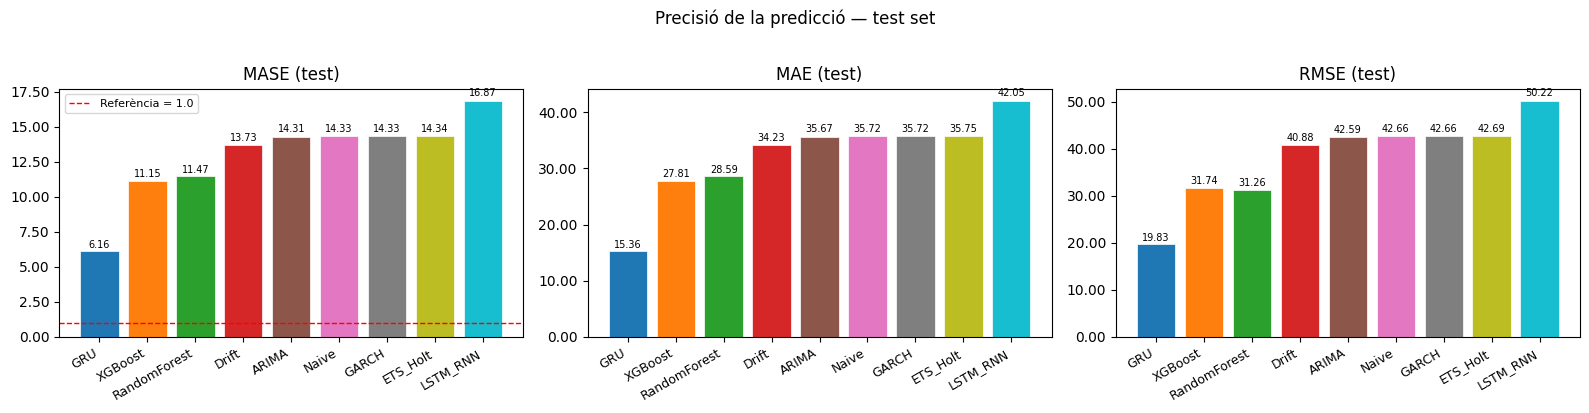

In [3]:
models   = summary.index.tolist()
n        = len(models)
x        = np.arange(n)
colors   = plt.cm.tab10(np.linspace(0, 1, n))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, ref in [
    (axes[0], "test_mase",   "MASE (test)",  1.0),
    (axes[1], "test_mae",    "MAE (test)",   None),
    (axes[2], "test_rmse",   "RMSE (test)",  None),
]:
    vals = summary[col].values
    bars = ax.bar(x, vals, color=colors, edgecolor="white", linewidth=0.5)
    if ref is not None:
        ax.axhline(ref, color="red", linestyle="--", linewidth=1, label=f"Referència = {ref}")
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    # Etiqueta valor sobre la barra
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Precisió de la predicció — test set", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Calibració dels intervals de confiança

Una cobertura ideal és exactament igual al nivell nominal (IC 80% → 80%, IC 95% → 95%).
Barres per sobre: intervals massa amples (model massa conservador).
Barres per sota: intervals massa estrets (model subestima la incertesa).

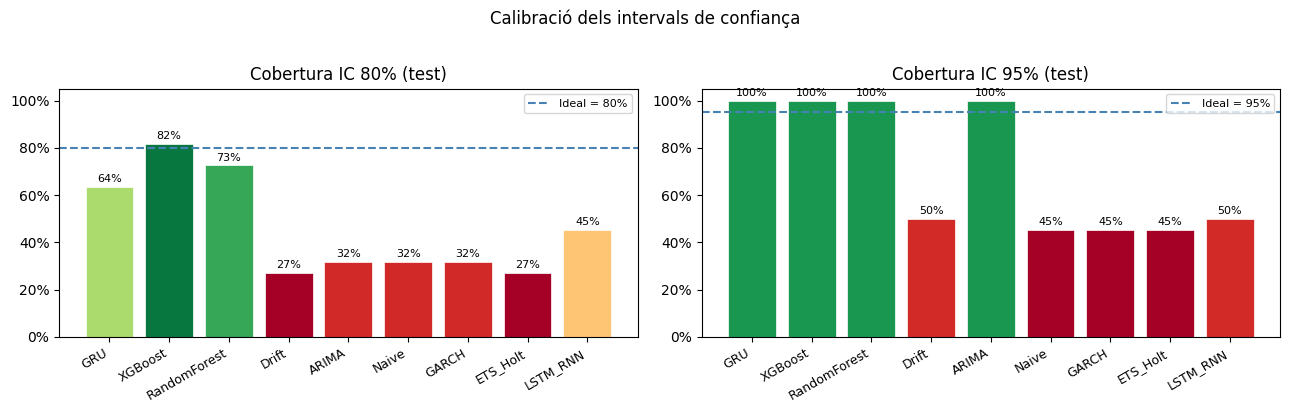

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, nominal, title in [
    (axes[0], "test_coverage_80", 0.80, "Cobertura IC 80% (test)"),
    (axes[1], "test_coverage_95", 0.95, "Cobertura IC 95% (test)"),
]:
    vals  = summary[col].values
    errs  = np.abs(vals - nominal)
    c_map = plt.cm.RdYlGn_r(errs / errs.max() if errs.max() > 0 else errs)
    bars  = ax.bar(x, vals, color=c_map, edgecolor="white", linewidth=0.5)
    ax.axhline(nominal, color="steelblue", linestyle="--", linewidth=1.5, label=f"Ideal = {nominal:.0%}")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(title)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.0%}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Calibració dels intervals de confiança", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Estabilitat CV — MAE per fold (variabilitat entre folds)

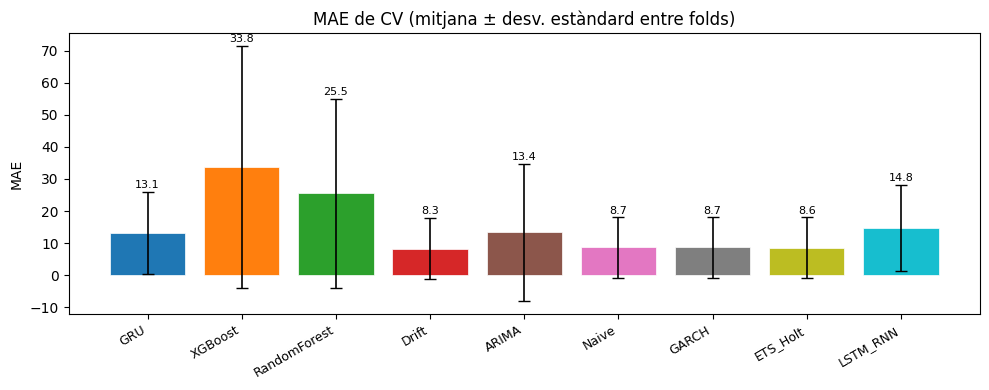

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

cv_means = summary["cv_mae_mean"].values
cv_stds  = summary["cv_mae_std"].values

bars = ax.bar(x, cv_means, yerr=cv_stds, capsize=4, color=colors,
              edgecolor="white", linewidth=0.5, error_kw={"elinewidth": 1.2})
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("MAE")
ax.set_title("MAE de CV (mitjana ± desv. estàndard entre folds)")
for bar, m, s in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.5,
            f"{m:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 5. Ranking final i recomanació

In [6]:
# Rank per cada mètrica (1 = millor)
ranking = pd.DataFrame(index=df.index)
ranking["rank_mase"]     = df["test_mase"].rank()
ranking["rank_rmse"]     = df["test_rmse"].rank()
ranking["rank_cv_mae"]   = df["cv_mae_mean"].rank()
ranking["rank_cov_80"]   = (df["test_coverage_80"] - 0.80).abs().rank()
ranking["rank_cov_95"]   = (df["test_coverage_95"] - 0.95).abs().rank()
ranking["rank_mitjà"]    = ranking.mean(axis=1)

ranking = ranking.sort_values("rank_mitjà")

print("=== RANKING FINAL (rank_mitjà baix = millor) ===")
print(ranking[["rank_mase", "rank_rmse", "rank_cv_mae",
               "rank_cov_80", "rank_cov_95", "rank_mitjà"]].round(2).to_string())

best = ranking.index[0]
print(f"\n>>> Model recomanat: {best}")
print(json.dumps({k: v for k, v in df.loc[best].items()}, indent=2))

=== RANKING FINAL (rank_mitjà baix = millor) ===
              rank_mase  rank_rmse  rank_cv_mae  rank_cov_80  rank_cov_95  rank_mitjà
model                                                                                
GRU                 1.0        1.0          5.0          3.0          2.5         2.5
RandomForest        3.0        2.0          8.0          2.0          2.5         3.5
XGBoost             2.0        3.0          9.0          1.0          2.5         3.5
Drift               4.0        4.0          1.0          8.5          5.5         4.6
ARIMA               5.0        5.0          6.0          6.0          2.5         4.9
GARCH               7.0        6.0          3.0          6.0          8.0         6.0
Naive               6.0        7.0          4.0          6.0          8.0         6.2
ETS_Holt            8.0        8.0          2.0          8.5          8.0         6.9
LSTM_RNN            9.0        9.0          7.0          4.0          5.5         6.9

>>> 